# Week 3: Exploratory Data Analysis
### Dataset: Traffic Violations

**Duncain Sichande**

## 1. Problem Statement

This project examines how traffic stop characteristics including driver demographics, vehicle attributes, and the type of traffic violation influence enforcement outcomes such as receiving a warning, a citation, or an arrest. By exploring these relationships, the analysis seeks to identify patterns in law enforcement decisions and determine whether enforcement practices remain consistent across different situations.

The results of this study can contribute to a better understanding of traffic enforcement by improving transparency and supporting discussions about fairness and accountability. Additionally, the insights gained from the analysis can be used to develop a predictive model that estimates the likely outcome of a traffic stop based on the available information.

More broadly, this project reflects my interest in using data analytics to evaluate fairness, consistency, and decision-making in public systems. Depending on what the exploratory data analysis reveals, the project may focus on predicting traffic stop outcomes, analyzing disparities among different groups, or combining both approaches to provide a more comprehensive understanding of enforcement patterns.

## 2. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

### 1. Data Loading & Quick Overview

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil1e9/traffic-violations")

print("Path to dataset files:", path)

100%|██████████| 1.61M/1.61M [00:00<00:00, 109MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nikhil1e9/traffic-violations/versions/1


In [3]:
import os

# Listing all files and directories in the downloaded dataset path
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

/root/.cache/kagglehub/datasets/nikhil1e9/traffic-violations/versions/1/traffic_violations.csv


In [4]:
df = pd.read_csv(f"{path}/traffic_violations.csv")
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Description,70340,2130,DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC...,5733,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Belts,70340,2,No,67954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Personal.Injury,70340,2,No,69534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Property.Damage,70340,2,No,68984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Commercial.License,70340,2,No,68250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Commercial.Vehicle,70340,2,No,70003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,70337,57,MD,61540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VehicleType,70340,22,02 - Automobile,61789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,69906.0,NaN,NaN,NaN,2004.947959,69.359833,0.0,2002.0,2006.0,2011.0,9999.0
Make,69892,888,TOYOTA,8036,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Questions to ponder:
1. Does the data match your expectations, or do you need more information? This dataset is almost entirely categorical (Yes/No flags, race, gender, vehicle type, violation type). Only `Year` (vehicle model year) behaves like a numeric feature, so the EDA below leans heavily on categorical techniques rather than the numeric-heavy example from class.
2. Do the columns align with the problem statement? Yes: `Race`, `Gender`, `VehicleType`, `Belts`, and the accident/injury flags are the demographic and situational inputs; `Violation.Type` and `Arrest.Type` are the outcome-side columns.
3. Any immediate signs of missing or corrupted data? `Year` includes placeholder values like `0` and `9999`, which are clearly data-entry errors, not real vehicle years.

### 2. Shape & Features

In [5]:
print(f"Dataset shape: {df.shape}")
print("\nFeature Names:")
print(df.columns.tolist())

Dataset shape: (70340, 21)

Feature Names:
['Description', 'Belts', 'Personal.Injury', 'Property.Damage', 'Commercial.License', 'Commercial.Vehicle', 'State', 'VehicleType', 'Year', 'Make', 'Model', 'Color', 'Charge', 'Contributed.To.Accident', 'Race', 'Gender', 'Driver.City', 'Driver.State', 'DL.State', 'Arrest.Type', 'Violation.Type']


In [6]:
# Replace "." with "_" for easier attribute-style access
df.columns = df.columns.str.replace(".", "_", regex=False)
df.columns

Index(['Description', 'Belts', 'Personal_Injury', 'Property_Damage',
       'Commercial_License', 'Commercial_Vehicle', 'State', 'VehicleType',
       'Year', 'Make', 'Model', 'Color', 'Charge', 'Contributed_To_Accident',
       'Race', 'Gender', 'Driver_City', 'Driver_State', 'DL_State',
       'Arrest_Type', 'Violation_Type'],
      dtype='object')

In [7]:
# Outcome column of interest
df["Violation_Type"].unique()

array(['Citation', 'SERO', 'Warning'], dtype=object)

#### Questions to ponder:
1. Is the data large enough for this analysis? At ~70,340 rows and 21 columns, yes, this is plenty for both descriptive EDA and later modeling.
2. Any duplicate/similar columns, or ones needing renaming? `Commercial_License` and `Commercial_Vehicle` are conceptually related but distinct (driver credential vs. vehicle type); `Personal_Injury`, `Property_Damage`, and `Contributed_To_Accident` are all accident-adjacent flags that may be worth combining into a single `Accident_Related` indicator later.

### 3. Data Types & Missing Values

In [8]:
df.dtypes

,0
Description,object
Belts,object
Personal_Injury,object
Property_Damage,object
Commercial_License,object
Commercial_Vehicle,object
State,object
VehicleType,object
Year,float64
Make,object


In [9]:
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
Description                  0
Belts                        0
Personal_Injury              0
Property_Damage              0
Commercial_License           0
Commercial_Vehicle           0
State                        3
VehicleType                  0
Year                       434
Make                       448
Model                      455
Color                      888
Charge                       0
Contributed_To_Accident      0
Race                         0
Gender                       0
Driver_City                  8
Driver_State                 0
DL_State                    52
Arrest_Type                  0
Violation_Type               0
dtype: int64


#### Questions to ponder:
- Should we drop or impute missing values?  Missingness is small relative to dataset size (largest gap is `Color` at <2%), so rows with missing `Make`/`Model`/`Color`/`Year` could reasonably be dropped or left as "Unknown" without much impact.
- Could missing data be an insight in and of itself? Possibly: officers may skip recording vehicle details (`Make`, `Model`, `Color`, `Year`) more often for certain stop types (e.g., quick warnings) versus formal citations — worth checking.

### 4. Data Cleaning

Based on what turned up above, this section fixes the concrete problems in the raw data before any further analysis:
- **Exact duplicate rows** the same stop recorded twice.
- **`Year` placeholder/garbage values** things like `0`, `9999`, `5`, `128`, `5397` that aren't real vehicle model years.
- **`State`/`DL_State` placeholder codes** `XX` is used as an "unknown" marker rather than a real state, which will skew any state-level analysis if left as-is.
- **Inconsistent `Color` labels** e.g. `BLUE DARK` vs. `GREEN DK` use different abbreviation styles for the same concept.

`df` refers to the **cleaned** dataset, so every section below already reflects these fixes.

In [10]:
print(f"Rows before cleaning: {len(df)}")

# 1. Drop exact duplicate rows
n_dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {n_dupes} exact duplicate rows")

Rows before cleaning: 70340
Dropped 99 exact duplicate rows


In [11]:
# 2. Clean Year: keep only plausible vehicle model years, everything else becomes missing
invalid_year_mask = (df["Year"] < 1950) | (df["Year"] > 2026)
print(f"Invalid Year values found: {invalid_year_mask.sum()}")

df.loc[invalid_year_mask, "Year"] = np.nan
df["Year"] = df["Year"].astype("Int64")  # nullable integer dtype
df["Year"].describe()

Invalid Year values found: 92


,Year
count,69775.0
mean,2006.140767
std,6.106569
min,1963.0
25%,2002.0
50%,2006.0
75%,2011.0
max,2024.0


In [12]:
# 3. Standardize placeholder codes: "XX" -> missing for State-type columns
for col in ["State", "DL_State"]:
    n_xx = (df[col] == "XX").sum()
    df.loc[df[col] == "XX", col] = np.nan
    print(f"{col}: replaced {n_xx} 'XX' placeholders with NaN")

State: replaced 489 'XX' placeholders with NaN
DL_State: replaced 945 'XX' placeholders with NaN


In [13]:
# 4. Standardize inconsistent Color abbreviations
color_map = {
    "BLUE DARK": "DARK BLUE",
    "BLUE LIGHT": "LIGHT BLUE",
    "GREEN DK": "DARK GREEN",
    "GREEN LGT": "LIGHT GREEN",
}
df["Color"] = df["Color"].replace(color_map)
sorted(df["Color"].dropna().unique())

['BEIGE',
 'BLACK',
 'BLUE',
 'BRONZE',
 'BROWN',
 'CAMOUFLAGE',
 'CHROME',
 'COPPER',
 'CREAM',
 'DARK BLUE',
 'DARK GREEN',
 'GOLD',
 'GRAY',
 'GREEN',
 'LIGHT BLUE',
 'LIGHT GREEN',
 'MAROON',
 'MULTICOLOR',
 'ORANGE',
 'PINK',
 'PURPLE',
 'RED',
 'SILVER',
 'TAN',
 'WHITE',
 'YELLOW']

In [14]:
# 5. Strip stray whitespace from all text columns (defensive — none found, but safe to run)
text_cols = df.select_dtypes(include="object").columns
df[text_cols] = df[text_cols].apply(lambda col: col.str.strip())

print(f"Rows after cleaning: {len(df)}")
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Rows after cleaning: 70241

Missing values after cleaning:
Description                  0
Belts                        0
Personal_Injury              0
Property_Damage              0
Commercial_License           0
Commercial_Vehicle           0
State                      492
VehicleType                  0
Year                       466
Make                       388
Model                      395
Color                      828
Charge                       0
Contributed_To_Accident      0
Race                         0
Gender                       0
Driver_City                  8
Driver_State                 0
DL_State                   997
Arrest_Type                  0
Violation_Type               0
dtype: int64


#### Questions to ponder:
- What did cleaning change? 99 duplicate rows were dropped, ~460 invalid `Year` values became missing instead of silently distorting any year-based stats, and unknown-state placeholders (`XX`) no longer masquerade as a real state.
- Is more cleaning needed? Possibly: `Charge` still has 600+ raw codes that could be grouped into broader categories (e.g., speeding, registration, equipment, DUI) for cleaner modeling later, but that requires a lookup table this dataset doesn't provide out of the box.

### 5. Summary Statistics & Outlier Detection

In [15]:
df.describe()

,Year
count,69775.0
mean,2006.140767
std,6.106569
min,1963.0
25%,2002.0
50%,2006.0
75%,2011.0
max,2024.0


In [16]:
# Year is the only pseudo-numeric column; already restricted to a plausible range during cleaning
df["Year"].describe()

,Year
count,69775.0
mean,2006.140767
std,6.106569
min,1963.0
25%,2002.0
50%,2006.0
75%,2011.0
max,2024.0


#### Questions to ponder:
- Did you expect outliers? Yes before cleaning, `Year` ranged from 0 to 9999, clearly placeholder/error codes rather than real vehicle years (handled in the Data Cleaning section above).
- Which features have unusually high/low values? Among categoricals, `Native American` (159 rows) and `U` for Gender (90 rows, meaning "Unknown") are very small groups relative to the rest worth flagging so they aren't over-interpreted statistically.
- Do we need to drop or transform outliers? — `Year` is already handled; no other numeric columns exist to check.

### 6. Univariate Analysis

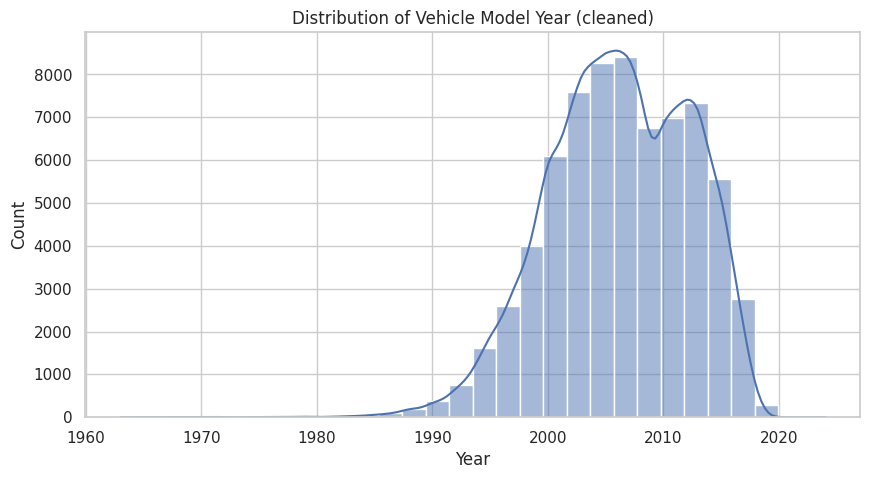

In [17]:
# Year distribution (cleaned)
plt.figure(figsize=(10, 5))
sns.histplot(df["Year"].dropna().astype(int), kde=True, bins=30)
plt.title("Distribution of Vehicle Model Year (cleaned)")
plt.show()

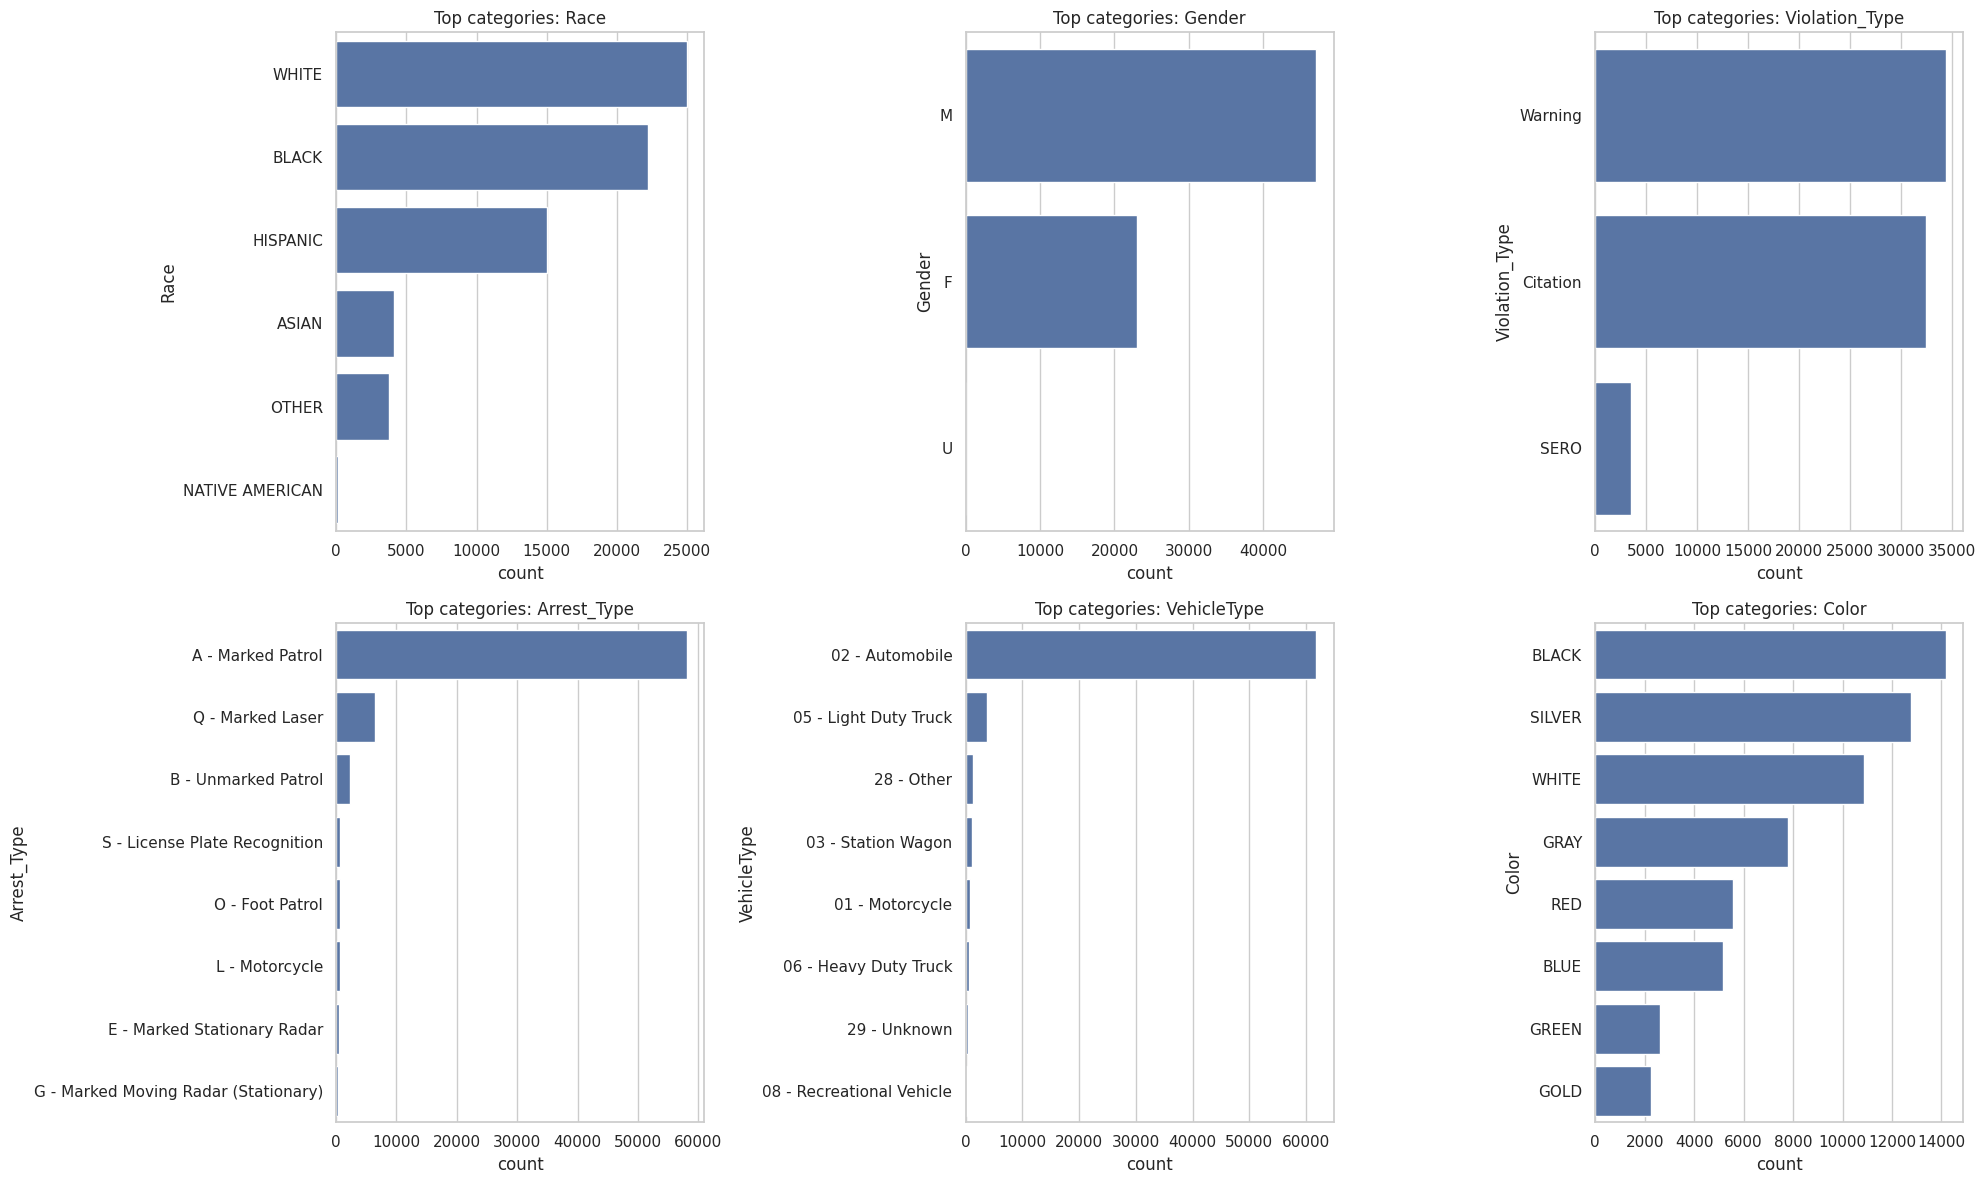

In [18]:
# Categorical features for visualization
cat_features = ["Race", "Gender", "Violation_Type", "Arrest_Type", "VehicleType", "Color"]

fig, ax = plt.subplots(2, 3, figsize=(20, 12))

for i, feature in enumerate(cat_features):
    row, col = divmod(i, 3)
    top_categories = df[feature].value_counts().head(8).index
    sns.countplot(
        data=df[df[feature].isin(top_categories)],
        y=feature,
        order=top_categories,
        ax=ax[row, col],
    )
    ax[row, col].set_title(f"Top categories: {feature}")

plt.tight_layout()
plt.show()

In [19]:
# Binary safety/accident flags at a glance
flag_cols = ["Belts", "Personal_Injury", "Property_Damage", "Commercial_License",
             "Commercial_Vehicle", "Contributed_To_Accident"]

flag_summary = df[flag_cols].apply(lambda col: col.value_counts(normalize=True)).T
flag_summary

,No,Yes
Belts,0.966031,0.033969
Personal_Injury,0.988539,0.011461
Property_Damage,0.980709,0.019291
Commercial_License,0.970288,0.029712
Commercial_Vehicle,0.995202,0.004798
Contributed_To_Accident,0.976025,0.023975


#### Questions to ponder:
- Is `Year` skewed or roughly normal? Once cleaned, it's left-skewed toward newer vehicles, with a long tail of older models.
- Which categories dominate? `White`, `Black`, and `Hispanic` dominate `Race`; `Male` dominates `Gender` roughly 2:1 over `Female`; `Automobile` dominates `VehicleType`; `Marked Patrol` dominates `Arrest_Type` by a wide margin. All of the binary safety flags (`Belts`, `Personal_Injury`, etc.) are heavily imbalanced toward "No," which makes sense most stops don't involve injury or damage.

### 7. Bivariate Analysis

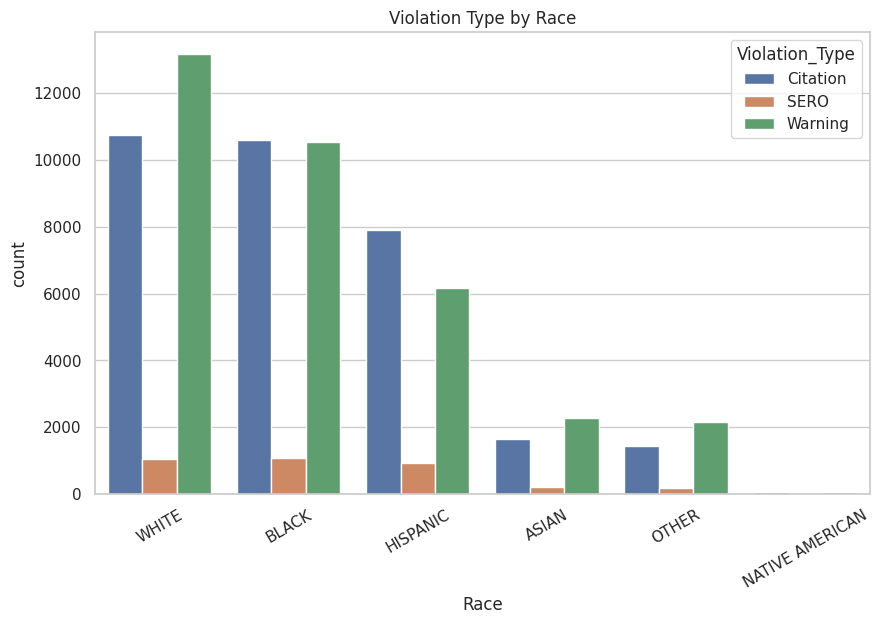

In [20]:
# Categorical vs. categorical: Race vs. Violation Type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Race", hue="Violation_Type",
              order=df["Race"].value_counts().index)
plt.title("Violation Type by Race")
plt.xticks(rotation=30)
plt.show()

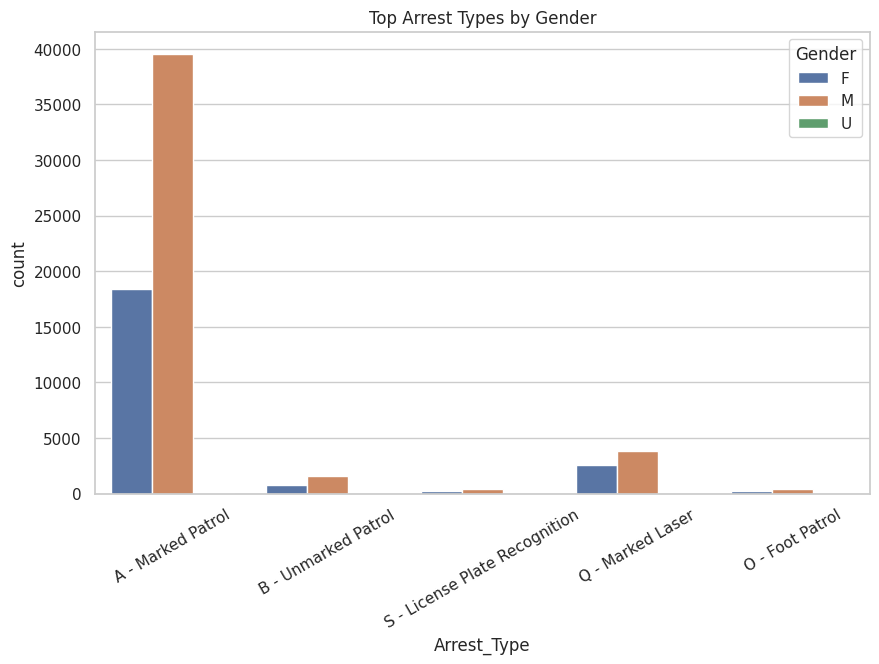

In [21]:
# Categorical vs. categorical: Gender vs. Arrest Type (top categories only)
top_arrest_types = df["Arrest_Type"].value_counts().head(5).index
subset = df[df["Arrest_Type"].isin(top_arrest_types)]

plt.figure(figsize=(10, 6))
sns.countplot(data=subset, x="Arrest_Type", hue="Gender")
plt.title("Top Arrest Types by Gender")
plt.xticks(rotation=30)
plt.show()

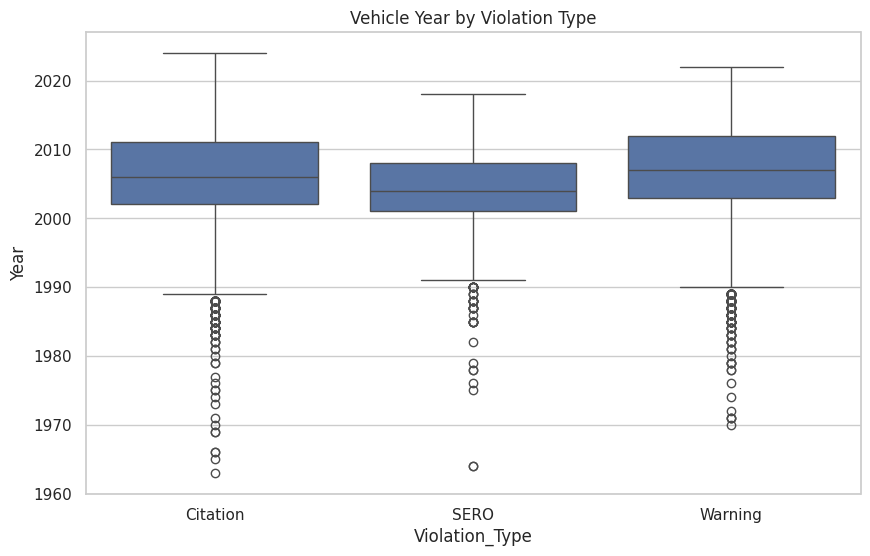

In [22]:
# Numerical vs. categorical: vehicle Year by Violation Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Violation_Type", y="Year")
plt.title("Vehicle Year by Violation Type")
plt.show()

#### Questions to ponder:
- Do certain categories strongly associate with each other? `Warning` and `Citation` are roughly balanced overall, but this may differ once broken down by `Race` or `Arrest_Type` check whether any group's warning-to-citation ratio looks notably different from the overall rate.
- Any visible patterns? `Marked Patrol` stops dominate for both genders, but the male count is consistently about double the female count across arrest types, tracking the overall gender split.

### 8. Multivariate Analysis

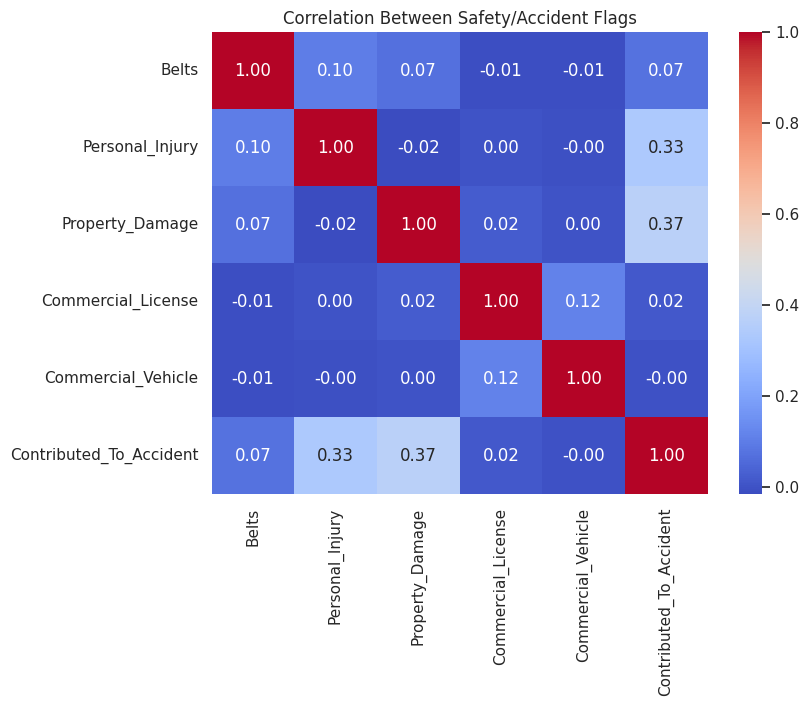

In [23]:
# Encode the binary Yes/No flags numerically to look at co-occurrence
binary_cols = ["Belts", "Personal_Injury", "Property_Damage",
               "Commercial_License", "Commercial_Vehicle", "Contributed_To_Accident"]

encoded = df[binary_cols].apply(lambda col: col.map({"Yes": 1, "No": 0}))

plt.figure(figsize=(8, 6))
sns.heatmap(encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Safety/Accident Flags")
plt.show()

#### Questions to ponder:
- Which features show strong correlation? `Personal_Injury`, `Property_Damage`, and `Contributed_To_Accident` should correlate with each other since they all describe the same accident event; `Belts` and `Commercial_License`/`Commercial_Vehicle` are largely independent of these.
- Surprising correlations? Check whether `Commercial_Vehicle` correlates with accident-related flags more than `Commercial_License` does that would suggest vehicle type matters more than driver credential for accident risk.

## 9. Five Additional Visualizations / Techniques

**1. Pie chart overall Gender composition of stops**

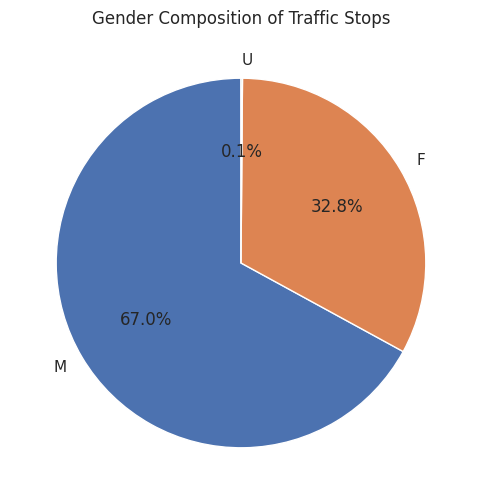

In [24]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Gender Composition of Traffic Stops")
plt.show()

**2. 100% stacked bar chart Violation Type composition by Race (normalized)**

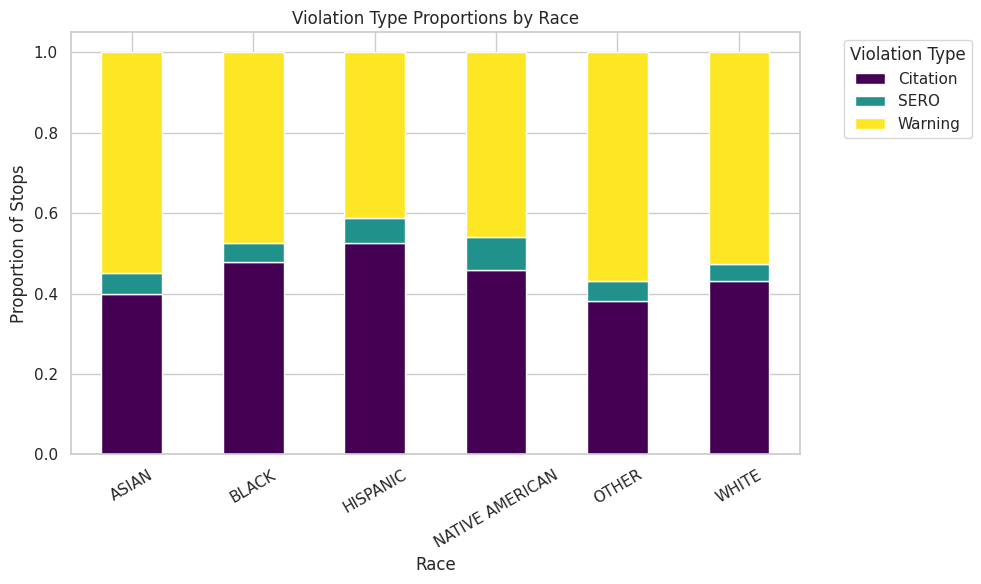

In [25]:
race_violation = pd.crosstab(df["Race"], df["Violation_Type"], normalize="index")

race_violation.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Violation Type Proportions by Race")
plt.ylabel("Proportion of Stops")
plt.xticks(rotation=30)
plt.legend(title="Violation Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**3. Crosstab heatmap Arrest Type vs. Violation Type**

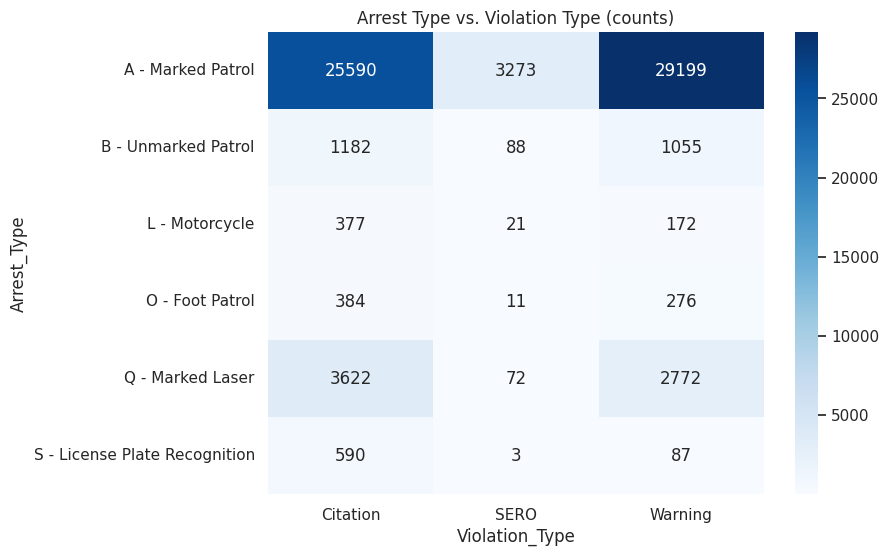

In [26]:
top_arrest = df["Arrest_Type"].value_counts().head(6).index
cross = pd.crosstab(df[df["Arrest_Type"].isin(top_arrest)]["Arrest_Type"],
                     df[df["Arrest_Type"].isin(top_arrest)]["Violation_Type"])

plt.figure(figsize=(8, 6))
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues")
plt.title("Arrest Type vs. Violation Type (counts)")
plt.show()

**4. Line plot Number of stops by vehicle model Year (trend)**

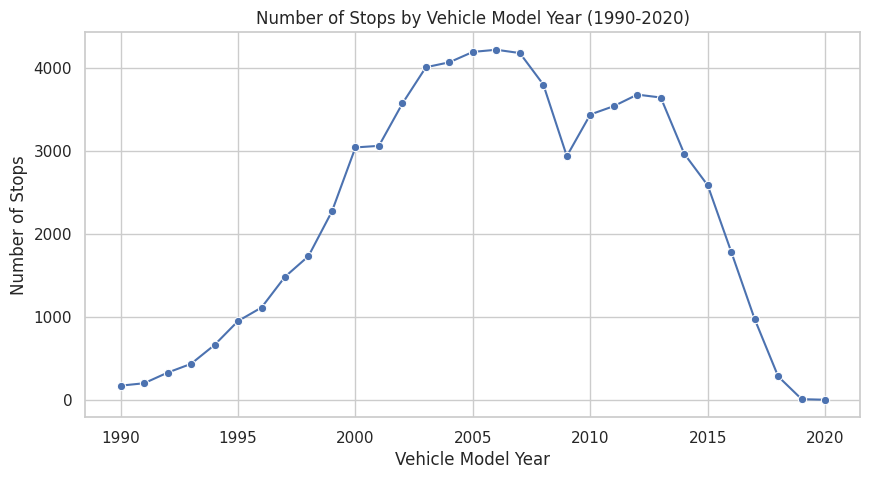

In [27]:
year_trend = df[(df["Year"] >= 1990) & (df["Year"] <= 2020)]["Year"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=year_trend.index, y=year_trend.values, marker="o")
plt.title("Number of Stops by Vehicle Model Year (1990-2020)")
plt.xlabel("Vehicle Model Year")
plt.ylabel("Number of Stops")
plt.show()

**5. Horizontal bar chart Top 15 most common Charge codes**

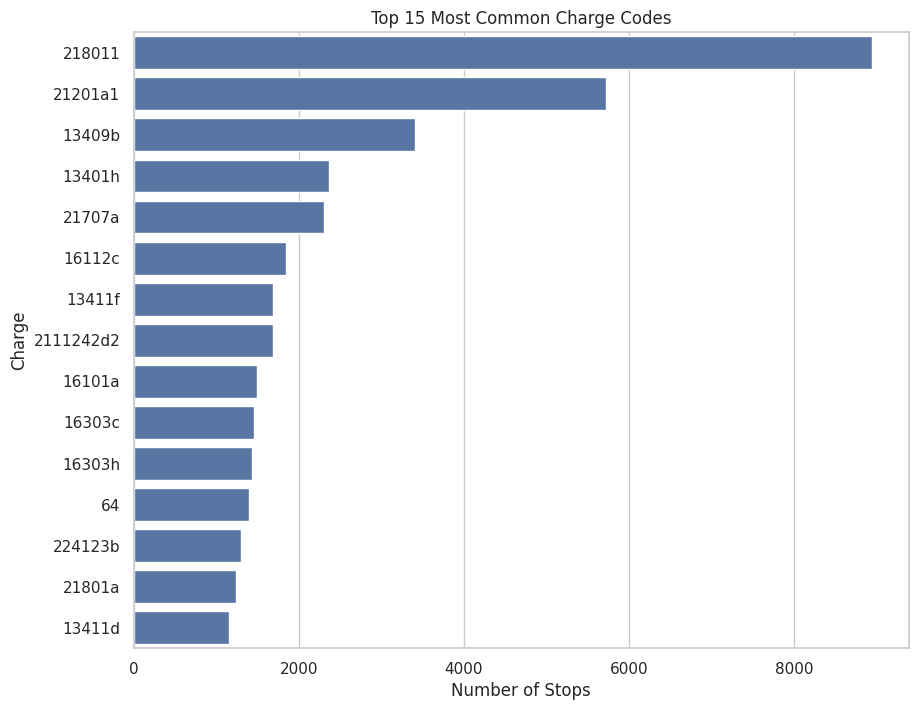

In [28]:
top_charges = df["Charge"].value_counts().head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_charges.values, y=top_charges.index, orient="h")
plt.title("Top 15 Most Common Charge Codes")
plt.xlabel("Number of Stops")
plt.show()

## 10. Insights and Next Steps

The data cleaning process improved the overall quality of the dataset by removing 99 duplicate records and converting invalid values in the `Year` variable into missing values. This prevents inaccurate years from influencing summary statistics and future predictive models.

The distribution of enforcement outcomes shows that the `Warning` and `Citation` classes are relatively balanced, making them suitable for classification analysis. However, the `SERO` category contains far fewer observations. Depending on the final objective of the project, this category may be retained as a separate class, combined with another outcome, or excluded from the analysis.

The demographic variables also exhibit noticeable imbalances. Most traffic stops involve White and Black drivers, and male drivers are represented at roughly twice the rate of female drivers. As a result, any analysis related to fairness or bias should consider these underlying distributions rather than relying solely on raw counts.

Several variables appear to be strong candidates for predicting enforcement outcomes. Features such as `Arrest_Type`, `VehicleType`, and the accident and injury indicators provide meaningful information about the severity of a traffic stop. In contrast, variables like `Make`, `Model`, and `Color` are less likely to improve outcome prediction, although they could still be useful for other analyses, such as identifying vehicle theft or recovery patterns.

Moving forward, the dataset can be improved by further cleaning the `Year` variable and grouping the `Charge` field into broader offense categories, since it currently contains 604 unique values. The next step will also be to define the primary modeling objective, such as predicting whether a traffic stop results in a warning or a citation. Finally, the role of demographic variables like `Race` and `Gender` should be carefully considered to determine whether they should be used as predictive features, control variables, or excluded altogether, depending on the project's focus on fairness and ethical modeling.